# Iris Neural Network Tutorial

This notebook explains not just how to train a neural network on Iris, but what the network is computing at each stage.

By the end you should be able to:
- explain what one hidden neuron computes: `x @ w + b`
- track tensor shapes through the network
- explain logits, softmax probabilities, and cross-entropy loss
- inspect one backward pass and one SGD weight update
- interpret a trained network through its decision regions and hidden representation

If your active kernel does not have PyTorch installed yet, run `%pip install torch matplotlib` in a cell before the imports.


In [1]:
import csv
from io import StringIO
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False)


## Why Iris?

Iris is a good first neural-network dataset because it is small enough to inspect directly.

Each flower has only four numeric features:
1. sepal length
2. sepal width
3. petal length
4. petal width

The task is to map those four numbers to one of three species.
Because the dataset is tiny, we can stop and examine the exact tensors, weights, activations, and gradients instead of treating the model as a black box.


Dataset shape: (150, 4)
First 3 flowers:
tensor([[5.100, 3.500, 1.400, 0.200],
        [4.900, 3.000, 1.400, 0.200],
        [4.700, 3.200, 1.300, 0.200]])
Class counts: {'setosa': 50, 'versicolor': 50, 'virginica': 50}


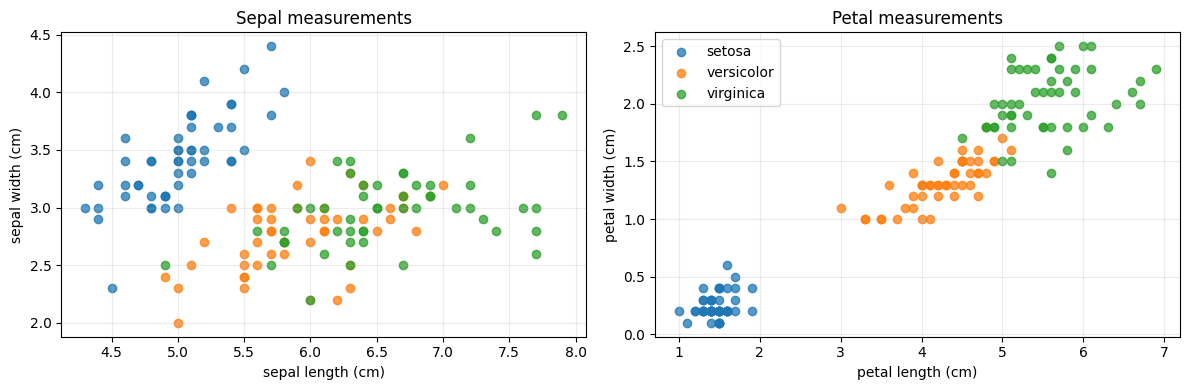

In [2]:
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
feature_names = [
    "sepal length",
    "sepal width",
    "petal length",
    "petal width",
]
class_names = ["setosa", "versicolor", "virginica"]
class_to_index = {f"Iris-{name}": index for index, name in enumerate(class_names)}
class_colors = ["tab:blue", "tab:orange", "tab:green"]

with urlopen(iris_url) as response:
    raw_csv = response.read().decode("utf-8").strip()

rows = [row for row in csv.reader(StringIO(raw_csv)) if row]
raw_features = torch.tensor(
    [[float(value) for value in row[:4]] for row in rows], dtype=torch.float32
)
labels = torch.tensor([class_to_index[row[4]] for row in rows], dtype=torch.long)

print("Dataset shape:", tuple(raw_features.shape))
print("First 3 flowers:")
print(raw_features[:3])
print(
    "Class counts:",
    {class_names[i]: int(count) for i, count in enumerate(torch.bincount(labels))},
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feature_pairs = [(0, 1), (2, 3)]
titles = ["Sepal measurements", "Petal measurements"]

for ax, (x_idx, y_idx), title in zip(axes, feature_pairs, titles):
    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_idx
        ax.scatter(
            raw_features[mask, x_idx],
            raw_features[mask, y_idx],
            label=class_name,
            alpha=0.75,
            color=class_colors[class_idx],
        )
    ax.set_xlabel(f"{feature_names[x_idx]} (cm)")
    ax.set_ylabel(f"{feature_names[y_idx]} (cm)")
    ax.set_title(title)
    ax.grid(alpha=0.25)

axes[1].legend()
plt.tight_layout()
plt.show()


## Split And Standardize

We split the dataset before normalization and compute the mean and standard deviation on the training set only.

That matters for two reasons:
- it matches real deployment, where future test examples are unknown during training
- it avoids leaking test-set statistics into the preprocessing step

Standardization is helpful here because the four input features live on different numeric scales.


In [3]:
def stratified_split(features, labels, train_fraction=0.8, seed=42):
    generator = torch.Generator().manual_seed(seed)
    train_feature_parts = []
    train_label_parts = []
    test_feature_parts = []
    test_label_parts = []

    for class_idx in range(len(class_names)):
        class_indices = torch.nonzero(labels == class_idx, as_tuple=False).squeeze(1)
        shuffled = class_indices[
            torch.randperm(class_indices.numel(), generator=generator)
        ]
        train_count = int(train_fraction * shuffled.numel())
        train_idx = shuffled[:train_count]
        test_idx = shuffled[train_count:]
        train_feature_parts.append(features[train_idx])
        train_label_parts.append(labels[train_idx])
        test_feature_parts.append(features[test_idx])
        test_label_parts.append(labels[test_idx])

    train_features_raw = torch.cat(train_feature_parts, dim=0)
    train_labels = torch.cat(train_label_parts, dim=0)
    test_features_raw = torch.cat(test_feature_parts, dim=0)
    test_labels = torch.cat(test_label_parts, dim=0)

    train_perm = torch.randperm(train_features_raw.size(0), generator=generator)
    test_perm = torch.randperm(test_features_raw.size(0), generator=generator)
    return (
        train_features_raw[train_perm],
        train_labels[train_perm],
        test_features_raw[test_perm],
        test_labels[test_perm],
    )


(
    train_features_raw,
    train_labels,
    test_features_raw,
    test_labels,
) = stratified_split(raw_features, labels, train_fraction=0.8, seed=42)

feature_mean = train_features_raw.mean(dim=0, keepdim=True)
feature_std = train_features_raw.std(dim=0, keepdim=True)

train_features = (train_features_raw - feature_mean) / feature_std
test_features = (test_features_raw - feature_mean) / feature_std

train_dataset = TensorDataset(train_features, train_labels)
test_dataset = TensorDataset(test_features, test_labels)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train shape:", tuple(train_features.shape))
print("Test shape:", tuple(test_features.shape))
print("Training mean used for scaling:")
print(feature_mean.squeeze(0))
print("Training std used for scaling:")
print(feature_std.squeeze(0))
print("Mean of standardized training features:")
print(train_features.mean(dim=0))
print("Std of standardized training features:")
print(train_features.std(dim=0))
print(
    "Train class counts:",
    {class_names[i]: int(count) for i, count in enumerate(torch.bincount(train_labels))},
)
print(
    "Test class counts:",
    {class_names[i]: int(count) for i, count in enumerate(torch.bincount(test_labels))},
)


Train shape: (120, 4)
Test shape: (30, 4)
Training mean used for scaling:
tensor([5.858, 3.066, 3.768, 1.205])
Training std used for scaling:
tensor([0.847, 0.447, 1.776, 0.763])
Mean of standardized training features:
tensor([ 0.000, -0.000, -0.000, -0.000])
Std of standardized training features:
tensor([1., 1., 1., 1.])
Train class counts: {'setosa': 40, 'versicolor': 40, 'virginica': 40}
Test class counts: {'setosa': 10, 'versicolor': 10, 'virginica': 10}


## The Model

We will use one hidden layer with eight neurons.

Each hidden neuron computes a weighted sum of the four input features, adds a bias, and passes the result through `ReLU`:

`hidden = ReLU(x @ W1^T + b1)`

The output layer then mixes those hidden activations into three logits, one per species:

`logits = hidden @ W2^T + b2`

The model is intentionally small so the internal tensors stay readable.


In [4]:
class IrisNet(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=8, num_classes=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward_features(self, x):
        hidden_pre = self.fc1(x)
        hidden = F.relu(hidden_pre)
        logits = self.fc2(hidden)
        return logits, {
            "hidden_pre": hidden_pre,
            "hidden": hidden,
            "logits": logits,
        }

    def forward(self, x):
        logits, _ = self.forward_features(x)
        return logits


def count_parameters(module):
    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)


demo_model = IrisNet()
batch_features, batch_labels = next(iter(train_loader))

with torch.no_grad():
    batch_logits, batch_activations = demo_model.forward_features(batch_features)

rows = [
    ("input", tuple(batch_features.shape), "batch of standardized flowers"),
    ("fc1", tuple(batch_activations["hidden_pre"].shape), "8 weighted sums per flower"),
    ("ReLU", tuple(batch_activations["hidden"].shape), "negative values clipped to 0"),
    ("fc2", tuple(batch_logits.shape), "3 logits per flower"),
]

print(demo_model)
print()
print(f'{"stage":<10} {"shape":<18} explanation')
print("-" * 64)
for name, shape, explanation in rows:
    print(f'{name:<10} {str(shape):<18} {explanation}')
print("-" * 64)
print("fc1 weight shape:", tuple(demo_model.fc1.weight.shape))
print("fc2 weight shape:", tuple(demo_model.fc2.weight.shape))
print("fc1 parameters: 8 * (4 + 1) =", demo_model.fc1.weight.numel() + demo_model.fc1.bias.numel())
print("fc2 parameters: 3 * (8 + 1) =", demo_model.fc2.weight.numel() + demo_model.fc2.bias.numel())
print("Total trainable parameters:", count_parameters(demo_model))


IrisNet(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)

stage      shape              explanation
----------------------------------------------------------------
input      (16, 4)            batch of standardized flowers
fc1        (16, 8)            8 weighted sums per flower
ReLU       (16, 8)            negative values clipped to 0
fc2        (16, 3)            3 logits per flower
----------------------------------------------------------------
fc1 weight shape: (8, 4)
fc2 weight shape: (3, 8)
fc1 parameters: 8 * (4 + 1) = 40
fc2 parameters: 3 * (8 + 1) = 27
Total trainable parameters: 67


## One Flower Through The Network

A full batch can hide what is happening. The next cell follows one flower through the untrained network and manually recomputes two values:
- the first hidden neuron's pre-activation
- the first output logit

The values are random because the model is still untrained, but the mechanics are exactly the same after training.


Standardized input flower:
tensor([-0.069, -0.818,  0.750,  0.911])
True class: virginica

First hidden neuron
weights:
tensor([ 0.382,  0.415, -0.117,  0.459])
elementwise products:
tensor([-0.026, -0.339, -0.088,  0.418])
Manual weighted sum + bias: 0.3510
Model value from fc1: 0.3510
After ReLU: 0.3510

All hidden pre-activations:
tensor([ 0.351,  0.093,  0.518,  0.345, -0.068,  0.618, -0.109,  0.194])
All hidden activations after ReLU:
tensor([0.351, 0.093, 0.518, 0.345, 0.000, 0.618, 0.000, 0.194])

Manual logit for class 0: 0.2355
Model logit for class 0: 0.2355
Logits:
tensor([ 0.235, -0.052,  0.216])
Softmax probabilities:
tensor([0.366, 0.275, 0.359])
Probability sum: 1.0000


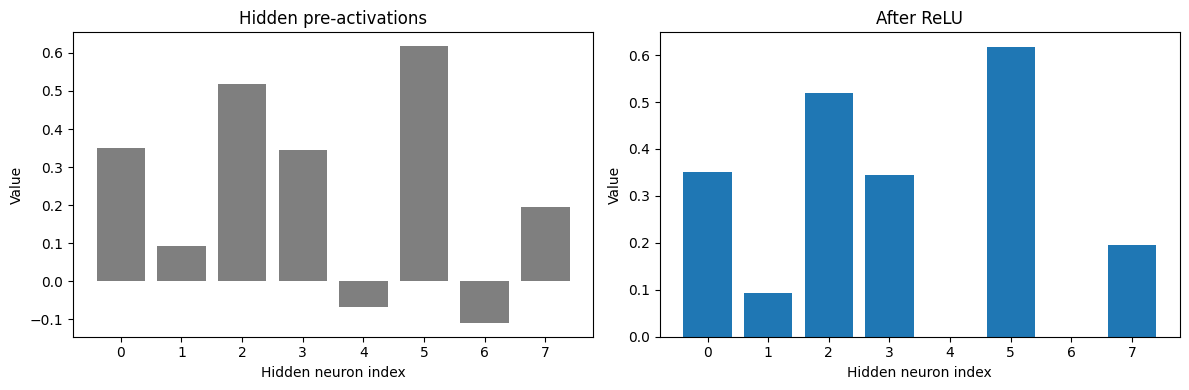

In [5]:
example_features, example_label_tensor = train_dataset[0]
example_label = example_label_tensor.item()

with torch.no_grad():
    single_logits, single_activations = demo_model.forward_features(example_features.unsqueeze(0))
    single_probabilities = torch.softmax(single_logits, dim=1)

first_hidden_weights = demo_model.fc1.weight[0].detach()
first_hidden_bias = demo_model.fc1.bias[0].detach()
hidden_products = example_features * first_hidden_weights
manual_hidden_pre = hidden_products.sum() + first_hidden_bias
manual_hidden_post = manual_hidden_pre.clamp_min(0.0)

first_output_weights = demo_model.fc2.weight[0].detach()
first_output_bias = demo_model.fc2.bias[0].detach()
manual_logit0 = (single_activations["hidden"][0] * first_output_weights).sum() + first_output_bias

print("Standardized input flower:")
print(example_features)
print("True class:", class_names[example_label])
print()
print("First hidden neuron")
print("weights:")
print(first_hidden_weights)
print("elementwise products:")
print(hidden_products)
print("Manual weighted sum + bias:", f"{manual_hidden_pre.item():.4f}")
print("Model value from fc1:", f"{single_activations['hidden_pre'][0, 0].item():.4f}")
print("After ReLU:", f"{manual_hidden_post.item():.4f}")
print()
print("All hidden pre-activations:")
print(single_activations["hidden_pre"].squeeze(0))
print("All hidden activations after ReLU:")
print(single_activations["hidden"].squeeze(0))
print()
print("Manual logit for class 0:", f"{manual_logit0.item():.4f}")
print("Model logit for class 0:", f"{single_logits[0, 0].item():.4f}")
print("Logits:")
print(single_logits.squeeze(0))
print("Softmax probabilities:")
print(single_probabilities.squeeze(0))
print("Probability sum:", f"{single_probabilities.sum().item():.4f}")

hidden_indices = torch.arange(single_activations["hidden"].shape[1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(hidden_indices, single_activations["hidden_pre"].squeeze(0).tolist(), color="tab:gray")
axes[0].set_title("Hidden pre-activations")
axes[0].set_xlabel("Hidden neuron index")
axes[0].set_ylabel("Value")

axes[1].bar(hidden_indices, single_activations["hidden"].squeeze(0).tolist(), color="tab:blue")
axes[1].set_title("After ReLU")
axes[1].set_xlabel("Hidden neuron index")
axes[1].set_ylabel("Value")
plt.tight_layout()
plt.show()


## Loss, Backprop, And One Update

`CrossEntropyLoss` expects logits and integer class labels.
For one example, the loss is the negative log-probability assigned to the true class.

After the forward pass computes the loss, `loss.backward()` uses the chain rule to populate gradients for every trainable parameter.
`optimizer.step()` then moves each weight in the direction that reduces the loss.


In [6]:
single_label = example_label_tensor.unsqueeze(0)
single_loss = F.cross_entropy(single_logits, single_label)
manual_loss = -torch.log(single_probabilities[0, example_label])

print("Cross-entropy on one example:", f"{single_loss.item():.4f}")
print("Manual -log(p_true):", f"{manual_loss.item():.4f}")
print("True-class probability:", f"{single_probabilities[0, example_label].item():.4f}")


def inspect_training_step(model, batch_features, batch_labels, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer.zero_grad()

    logits, activations = model.forward_features(batch_features)
    loss = F.cross_entropy(logits, batch_labels)
    loss.backward()

    tracked_before = model.fc1.weight[0, 0].item()
    tracked_grad = model.fc1.weight.grad[0, 0].item()
    expected_after = tracked_before - lr * tracked_grad
    fc1_grad_norm = model.fc1.weight.grad.norm().item()
    fc2_grad_norm = model.fc2.weight.grad.norm().item()
    first_probs = torch.softmax(logits[0].detach(), dim=0)
    first_pred = logits.argmax(dim=1)[0].item()

    print("Batch shape:", tuple(batch_features.shape))
    print("Hidden activation shape:", tuple(activations["hidden"].shape))
    print("Logits shape:", tuple(logits.shape))
    print("Loss before update:", f"{loss.item():.4f}")
    print("First sample true class:", class_names[batch_labels[0].item()])
    print("First sample predicted class:", class_names[first_pred])
    print("First sample probabilities:")
    print(first_probs)
    print("Gradient norm for fc1 weights:", f"{fc1_grad_norm:.4f}")
    print("Gradient norm for fc2 weights:", f"{fc2_grad_norm:.4f}")

    optimizer.step()
    actual_after = model.fc1.weight[0, 0].item()
    print("Tracked weight before update:", f"{tracked_before:.6f}")
    print("Its gradient:", f"{tracked_grad:.6f}")
    print("Expected SGD update old - lr * grad:", f"{expected_after:.6f}")
    print("Actual value after optimizer.step():", f"{actual_after:.6f}")


step_model = IrisNet()
mini_batch_features, mini_batch_labels = next(iter(train_loader))
inspect_training_step(step_model, mini_batch_features, mini_batch_labels, lr=0.1)


Cross-entropy on one example: 1.0242
Manual -log(p_true): 1.0242
True-class probability: 0.3591


Batch shape: (16, 4)
Hidden activation shape: (16, 8)
Logits shape: (16, 3)
Loss before update: 1.0704
First sample true class: virginica
First sample predicted class: setosa
First sample probabilities:
tensor([0.363, 0.307, 0.329])
Gradient norm for fc1 weights: 0.3608
Gradient norm for fc2 weights: 0.5001
Tracked weight before update: 0.166626
Its gradient: 0.072309
Expected SGD update old - lr * grad: 0.159395
Actual value after optimizer.step(): 0.159395


## Train The Network

Now we repeat that same forward and backward process for many batches.
The notebook uses plain SGD so the earlier `old_weight - lr * gradient` explanation matches the optimizer that actually trains the model.


Epoch   1: train loss 1.0677, train acc 0.500, test loss 0.9639, test acc 0.667
Epoch  25: train loss 0.1725, train acc 0.958, test loss 0.1479, test acc 0.967


Epoch  50: train loss 0.0818, train acc 0.975, test loss 0.0867, test acc 0.933


Epoch  75: train loss 0.0601, train acc 0.975, test loss 0.0757, test acc 0.967
Epoch 100: train loss 0.0486, train acc 0.983, test loss 0.0822, test acc 0.967
Epoch 125: train loss 0.0427, train acc 0.983, test loss 0.0804, test acc 0.967


Epoch 150: train loss 0.0388, train acc 0.983, test loss 0.0835, test acc 0.967


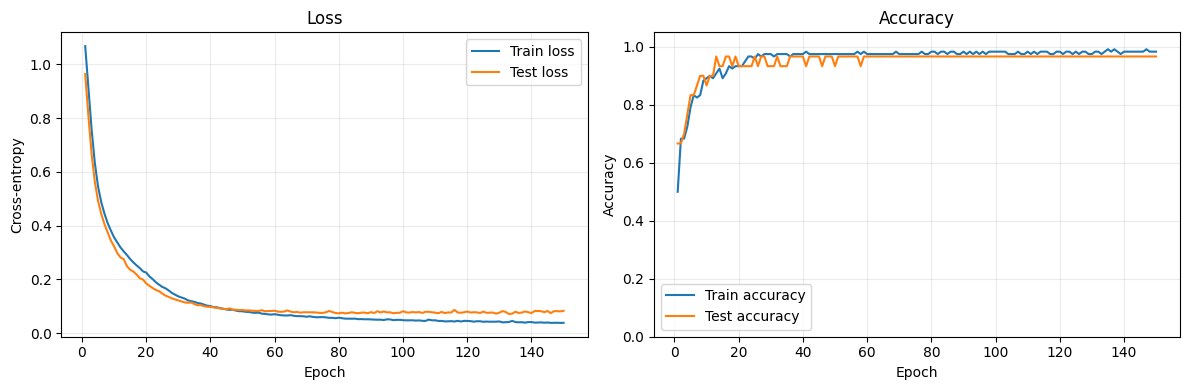

In [7]:
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    seen = 0

    with torch.no_grad():
        for batch_features, batch_labels in loader:
            logits = model(batch_features)
            total_loss += F.cross_entropy(logits, batch_labels, reduction="sum").item()
            predictions = logits.argmax(dim=1)
            correct += predictions.eq(batch_labels).sum().item()
            seen += batch_labels.size(0)

    return total_loss / seen, correct / seen


def fit(model, train_loader, test_loader, epochs=150, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        seen = 0

        for batch_features, batch_labels in train_loader:
            optimizer.zero_grad()
            logits = model(batch_features)
            loss = F.cross_entropy(logits, batch_labels)
            loss.backward()
            optimizer.step()

            batch_size = batch_labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += logits.argmax(dim=1).eq(batch_labels).sum().item()
            seen += batch_size

        train_loss = running_loss / seen
        train_accuracy = running_correct / seen
        test_loss, test_accuracy = evaluate_model(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        if epoch == 1 or epoch % 25 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:>3}: "
                f"train loss {train_loss:.4f}, train acc {train_accuracy:.3f}, "
                f"test loss {test_loss:.4f}, test acc {test_accuracy:.3f}"
            )

    return history


trained_model = IrisNet()
history = fit(trained_model, train_loader, test_loader, epochs=150, lr=0.1)

epoch_axis = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_axis, history["train_loss"], label="Train loss")
axes[0].plot(epoch_axis, history["test_loss"], label="Test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epoch_axis, history["train_accuracy"], label="Train accuracy")
axes[1].plot(epoch_axis, history["test_accuracy"], label="Test accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.05)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Evaluate And Interpret The Trained Network

After training, we can connect the math back to behavior.

The next cells answer four questions:
- how often is the model correct?
- which classes still get mixed up?
- what probabilities does the model assign to one test flower?
- how does the learned hidden representation reorganize the data?


Test accuracy: 0.967
Confusion matrix (rows = true, cols = predicted):
tensor([[10,  0,  0],
        [ 0,  9,  1],
        [ 0,  0, 10]])
Misclassified test examples:
  index 2: true = versicolor, predicted = virginica


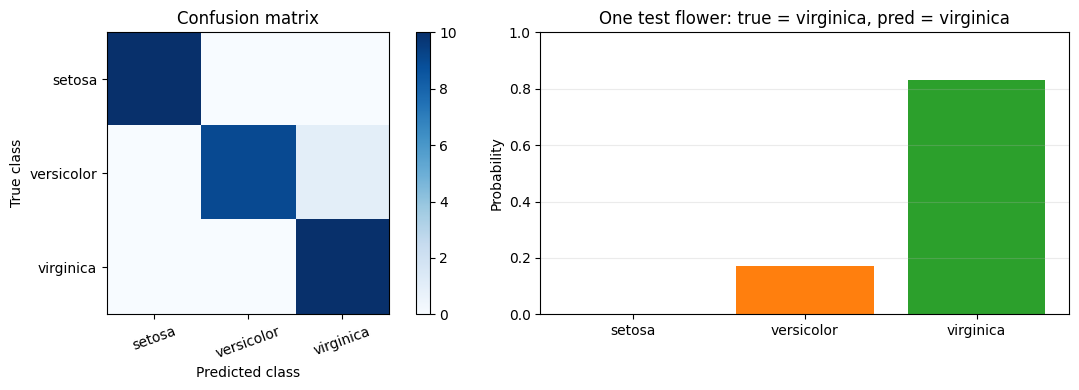

In [8]:
def build_confusion_matrix(targets, predictions, num_classes):
    confusion = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for target, prediction in zip(targets, predictions):
        confusion[target, prediction] += 1
    return confusion


trained_model.eval()
with torch.no_grad():
    train_logits, train_activations = trained_model.forward_features(train_features)
    test_logits, test_activations = trained_model.forward_features(test_features)
    test_probabilities = torch.softmax(test_logits, dim=1)
    test_predictions = test_probabilities.argmax(dim=1)

test_accuracy = test_predictions.eq(test_labels).float().mean().item()
confusion = build_confusion_matrix(test_labels, test_predictions, len(class_names))
print(f"Test accuracy: {test_accuracy:.3f}")
print("Confusion matrix (rows = true, cols = predicted):")
print(confusion)

wrong_indices = torch.nonzero(test_predictions != test_labels, as_tuple=False).squeeze(1)
if wrong_indices.numel() == 0:
    print("No misclassifications in this split.")
else:
    print("Misclassified test examples:")
    for index in wrong_indices.tolist():
        true_name = class_names[test_labels[index].item()]
        pred_name = class_names[test_predictions[index].item()]
        print(f"  index {index}: true = {true_name}, predicted = {pred_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

image = axes[0].imshow(confusion.numpy(), cmap="Blues")
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")
axes[0].set_xticks(range(len(class_names)), class_names, rotation=20)
axes[0].set_yticks(range(len(class_names)), class_names)
plt.colorbar(image, ax=axes[0])

sample_index = 0
sample_probs = test_probabilities[sample_index]
sample_true = class_names[test_labels[sample_index].item()]
sample_pred = class_names[test_predictions[sample_index].item()]
axes[1].bar(class_names, sample_probs.tolist(), color=class_colors)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Probability")
axes[1].set_title(f"One test flower: true = {sample_true}, pred = {sample_pred}")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


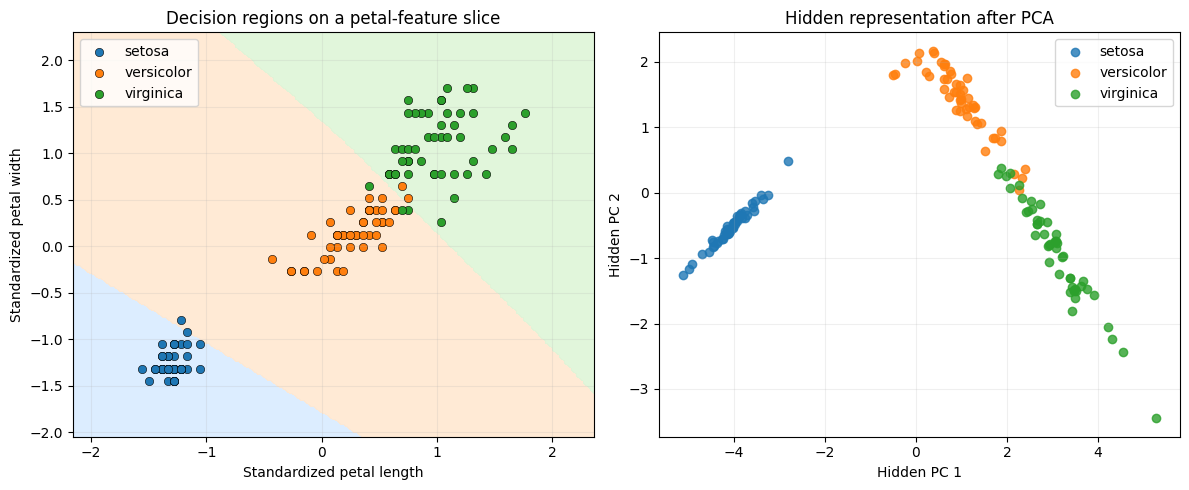

In [9]:
combined_features = torch.cat([train_features, test_features], dim=0)
combined_labels = torch.cat([train_labels, test_labels], dim=0)
petal_features = combined_features[:, 2:4]

x_min = petal_features[:, 0].min().item() - 0.6
x_max = petal_features[:, 0].max().item() + 0.6
y_min = petal_features[:, 1].min().item() - 0.6
y_max = petal_features[:, 1].max().item() + 0.6

grid_x, grid_y = torch.meshgrid(
    torch.linspace(x_min, x_max, 220),
    torch.linspace(y_min, y_max, 220),
    indexing="xy",
)
grid_inputs = torch.zeros(grid_x.numel(), 4)
grid_inputs[:, 2] = grid_x.reshape(-1)
grid_inputs[:, 3] = grid_y.reshape(-1)

with torch.no_grad():
    grid_predictions = trained_model(grid_inputs).argmax(dim=1).reshape(grid_x.shape)

background_cmap = ListedColormap(["#d9ecff", "#ffe8d1", "#def5d8"])

hidden_all = torch.cat(
    [train_activations["hidden"], test_activations["hidden"]], dim=0
)
centered_hidden = hidden_all - hidden_all.mean(dim=0, keepdim=True)
_, _, principal_directions = torch.pca_lowrank(centered_hidden, q=2)
hidden_2d = centered_hidden @ principal_directions[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contourf(
    grid_x.numpy(),
    grid_y.numpy(),
    grid_predictions.numpy(),
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=background_cmap,
    alpha=0.9,
)
for class_idx, class_name in enumerate(class_names):
    mask = combined_labels == class_idx
    axes[0].scatter(
        petal_features[mask, 0],
        petal_features[mask, 1],
        color=class_colors[class_idx],
        label=class_name,
        edgecolor="black",
        linewidth=0.4,
    )
axes[0].set_title("Decision regions on a petal-feature slice")
axes[0].set_xlabel("Standardized petal length")
axes[0].set_ylabel("Standardized petal width")
axes[0].legend()
axes[0].grid(alpha=0.2)

for class_idx, class_name in enumerate(class_names):
    mask = combined_labels == class_idx
    axes[1].scatter(
        hidden_2d[mask, 0],
        hidden_2d[mask, 1],
        color=class_colors[class_idx],
        label=class_name,
        alpha=0.8,
    )
axes[1].set_title("Hidden representation after PCA")
axes[1].set_xlabel("Hidden PC 1")
axes[1].set_ylabel("Hidden PC 2")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


## Takeaways

- A hidden neuron is just a weighted sum plus a bias, followed by a nonlinearity.
- ReLU keeps positive evidence and blocks negative responses.
- The final layer returns logits, not probabilities. Softmax converts logits into probabilities that sum to `1`.
- Cross-entropy gets smaller when the model assigns higher probability to the true class.
- Backpropagation fills in gradients for every parameter, and SGD applies `new_weight = old_weight - learning_rate * gradient`.
- The hidden layer learns a representation where the species become easier to separate.
